In [1]:
from sklearn.datasets import fetch_openml

In [2]:

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

we will be using the MNIST dataset, which is a set of 70,000 small  
images of digits handwritten by high school students and employees of the US Cen‐
sus Bureau.     
  Each image is labeled with the digit it represents.  
  This set has been stud‐
ied so much that it is often called the “hello world” of Machine Learning: whenever  
people come up with a new classification algorithm they are curious to see how it will  
perform on MNIST, and anyone who learns Machine Learning tackles this dataset  
sooner or later

In [3]:

X, y = mnist.data, mnist.target
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

In [5]:
print(X.shape)

(70000, 784)


In [6]:
import pandas as pd
# Combine into a DataFrame
df = pd.DataFrame(X)
df['label'] = y  # add target as a column

# Show first 5 rows like pd.head()
print(df.head())

   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  label  
0    0      5  
1    0      0  
2    0      4  
3    0      1  
4    0      9  

[5 rows x 785 columns]


There are 70,000 images, and each image has 784 features.  
 This is because each image is 28 × 28 pixels, and each feature simply represents one pixel’s intensity,  
  from 0 (white) to 255 (black). Let’s take a peek at one digit from the dataset.  
   All you need to do is grab an instance’s feature vector, reshape it to a 28 × 28 array,  
    and display it  using Matplotlib’s imshow() function:

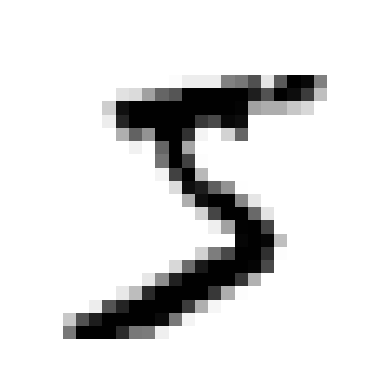

In [7]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [8]:
print(y[0])

5


This looks like a 5, and indeed that’s what the label tells us

Note that the label is a string. Most ML algorithms expect numbers, so let’s cast y to
integer

Creating test and train data

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Training a Binary Classifier  
Let’s simplify the problem for now and only try to identify one digit—for example,  
the number 5. This “5-detector” will be an example of a binary classifier, capable of  
distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for  
this classification task:

In [10]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [11]:
print(y_train_5)

[ True False False ...  True False False]


A good place to start is with a Stochastic Gradi‐
ent Descent (SGD) classifier,   using Scikit-Learn’s SGDClassifier class.  
 This classifier
has the advantage of being capable of handling very large datasets efficiently.  
 This is
in part because SGD deals with training instances independently, one at a time
(which also makes SGD well suited for online learning)

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [13]:
sgd_clf.predict([some_digit])


array([ True])

Measuring Accuracy with Cross-Validation in Machine Learning
1. Why We Measure Accuracy

In supervised machine learning, we want to know how well a model generalizes to unseen data. Accuracy is one of the most common metrics:

Accuracy
=
Correct Predictions
Total Predictions
Accuracy=
Total Predictions /
Correct Predictions
	​


But measuring accuracy on the same data used for training gives overly optimistic results. That’s why we split data into training and testing sets.

Limitations of a Single Train-Test Split

A common approach is an 80/20 split: train on 80%, test on 20%.

Problem: the accuracy you get depends on how the data was split.

A “lucky” split may give higher accuracy.

An “unlucky” split may give lower accuracy.

This makes the estimate unstable and unreliable.

Cross-Validation to the Rescue

Cross-validation solves this by systematically rotating the test set:

Step 1: Shuffle the dataset once (to mix samples).

Step 2: Split into k folds (say, 5 or 10). Each fold is an equal chunk of the dataset.

Step 3: Perform k rounds:

In each round, train on 
𝑘
−
1
k−1 folds (80% if k=5).

Test on the remaining fold (20% if k=5).

Record accuracy.

Step 4: Average the accuracies across folds:

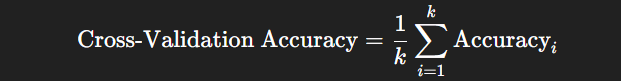

Example: 5-Fold Cross-Validation

Split data into 5 folds: F1, F2, F3, F4, F5.

Round 1: Train on F2–F5, test on F1.

Round 2: Train on F1, F3–F5, test on F2.

… repeat until each fold has been test set once.

Final result = average accuracy of all 5 rounds.

This ensures every sample is used once for testing and 
𝑘
−
1
k−1 times for training.

Why Cross-Validation Accuracy is Good

✅ Uses all data → nothing wasted.  
✅ Less bias → no dependency on a single split.  
✅ More reliable → stable estimate of performance.  
✅ Shows variability → standard deviation tells us if the model is consistent.  

In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Wow! Above 95% accuracy (ratio of correct predictions) on all cross-validation folds?  
 This looks amazing, doesn’t it? Well, before you get too excited, let’s look at a dummy classifier  
  that just classifies every single image in the most frequent class, which in this case is the negative class

In [15]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))  # prints False: no 5s detected

False


In [16]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

That’s right, it has over 90% accuracy! This is simply because only about 10% of the images are 5s,  
 so if you always guess that an image is not a 5, you will be right about 90% of the time. Beats Nostradamus.

This demonstrates why accuracy is generally not the preferred performance measure for classifiers,  
 especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).  
  A much better way to evaluate the performance of a classifier is to look at the confusion matrix (CM).

Implementing Cross-Validation
Occasionally you will need more control over the cross-validation process than what Scikit-Learn provides off the shelf.  
 In these cases, you can implement cross-validation yourself.  
  The following code does roughly the same thing as Scikit-Learn’s cross_val_score() function, and it prints the same result:

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is
                                       # not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))  # prints 0.95035, 0.96035, and 0.9604

0.95035
0.96035
0.9604


Confusion Matrix : A **Confusion Matrix** is a performance evaluation tool used to measure how well a classification model works.
It is a **table** that compares the actual values with the predicted values of the model.


📊 Structure of a Confusion Matrix (for binary classification)

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------- | ---------------------- | ---------------------- |
| **Actual Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual Negative** | False Positive (FP)    | True Negative (TN)     |

### 📌 Metrics Derived from Confusion Matrix

1. **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
2. **Precision** = TP / (TP + FP)
3. **Recall (Sensitivity, TPR)** = TP / (TP + FN)
4. **Specificity (TNR)** = TN / (TN + FP)
5. **F1 Score** = 2 × (Precision × Recall) / (Precision + Recall)

In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

In [19]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [20]:
print(y_train_pred)

[ True False False ...  True False False]


In [23]:
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

Each row in a confusion matrix represents an actual class, while each column represents a predicted class.  
 The first row of this matrix considers non-5 images (the negative class): 53,892 of them were correctly  
 classified as non-5s (they are called true negatives), while the remaining 687 were wrongly classified as 5s (false positives).  
 The second row considers the images of 5s (the positive class): 1891 were wrongly classified as non-5s (false negatives),  
  while the remaining 3530 were correctly classified as 5s (true positives). 
  A perfect classifier would have only true positives and true
negatives, so its confusion matrix would have nonzero values only   on its main diagonal (top left to bottom right):


Predent we reached perfection

In [24]:
y_train_pred_perfections = y_test_5
confusion_matrix(y_test_5, y_train_pred_perfections)

array([[9108,    0],
       [   0,  892]])

### 🎯 What is **Precision**?

Precision tells us **out of all the predictions the model made as Positive, how many were actually Positive**.

It focuses on the **quality of Positive predictions**.

**Precision** = TP / (TP + FP)

* **TP (True Positive):** Correctly predicted positive cases
* **FP (False Positive):** Incorrectly predicted positive cases

### 🔎 Example:

Suppose a model is predicting whether an email is **Spam** (Positive) or **Not Spam** (Negative).

* TP = 80 (Spam correctly identified as Spam)
* FP = 20 (Not Spam wrongly flagged as Spam)

$$
\text{Precision} = \frac{80}{80 + 20} = \frac{80}{100} = 0.8 \, (80\%)
$$

➡️ Meaning: **80% of emails marked as spam were actually spam.**

### ⚠️ Limitations of Precision (Simple Explanation)

* **Precision only checks how correct the positive predictions are.**
* It **doesn’t tell us about the missed positives** (false negatives).

### 🥼 Medical Test Analogy:

* Imagine a **test for a disease**.
* **High Precision:** If the test says you’re sick, you *really are sick* (few false alarms).
* **Limitation:** It doesn’t tell you how many **sick people it failed to detect**.

So the test looks good on paper (precise) but could still **miss a lot of sick patients** → that’s the weakness.

---

### 📩 Spam Filter Analogy:

* Precision says: “If I mark an email as spam, I’m usually right.”
* Limitation: It might let **many spam emails pass through** because it only cares about being *right when it does say spam*, not about *catching all spam*.

---

✅ In very simple words:
Precision is about **being careful**, but its limitation is that it may be **too careful and miss many real cases**.


### 🔎 **Recall (Sensitivity / True Positive Rate)**

Recall tells us **out of all the actual Positive cases, how many did the model correctly identify**.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

* **TP (True Positive):** Correctly predicted positives
* **FN (False Negative):** Missed positives

#### ✅ Example:

* TP = 80 (Spam correctly identified as Spam)
* FN = 40 (Spam missed as Not Spam)

$$
\text{Recall} = \frac{80}{80 + 40} = \frac{80}{120} = 0.67 \, (67\%)
$$

➡️ Meaning: The model found **67% of actual spam emails**.

In [25]:
from sklearn.metrics import precision_score, recall_score

In [26]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [27]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

## 📘 What is **F1 Score**?

The **F1 Score** is a way to **combine Precision and Recall into one single number**.
It’s useful because sometimes Precision is high but Recall is low (or the other way around), and we want a balance.

### 🧮 Formula:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

It is the **harmonic mean** of Precision and Recall (not just the average).
This makes it **high only when both Precision and Recall are high**.

### 🎯 Why F1 Score?

* If Precision is high but Recall is very low → F1 stays low.
* If Recall is high but Precision is very low → F1 stays low.
* Only if both are good → F1 is good.


### 📩 Example (Spam Filter):

* Precision = 0.8 (80%)
* Recall = 0.6 (60%)

$$
F1 = 2 \times \frac{0.8 \times 0.6}{0.8 + 0.6} 
= 2 \times \frac{0.48}{1.4} 
= 0.685 \, (68.5\%)
$$

➡️ So instead of looking at two separate numbers, we get one balanced score.

In [28]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

### 🧠 Intuition (New Example)

* **Precision** → *When I ring the fire alarm, how often is there actually a fire?* 🚨🔥
* **Recall** → *Out of all the real fires, how many times did I ring the alarm?*
* **F1 Score** → *I’m a good fire alarm only if I both:*

  1. Ring mostly at real fires (high precision)
  2. Don’t miss many real fires (high recall)

✅ So F1 makes sure you’re not just **accurate**, but also **catching enough cases**.

## 📘 Precision–Recall Tradeoff

### 🎯 What it means

* Precision and Recall often **move in opposite directions**.
* If you try to **increase Precision**, Recall usually goes down.
* If you try to **increase Recall**, Precision usually goes down.

---

### 🔎 Why does this happen?

It depends on the **decision threshold** (the cutoff probability for classifying something as Positive).

* **High threshold** → Model is very strict before saying “Positive.”

  * ✅ High Precision (few false alarms)
  * ❌ Low Recall (misses many actual positives)

* **Low threshold** → Model is lenient and says “Positive” more often.

  * ✅ High Recall (catches most positives)
  * ❌ Low Precision (many false alarms)

---

### 📩 Example (Spam Filter)

* If the filter only marks emails as spam when **100% sure** →

  * ✅ Almost no real emails are wrongly marked (High Precision).
  * ❌ Many spam emails sneak through (Low Recall).

* If the filter marks emails as spam when **60% sure** →

  * ✅ Almost all spam is caught (High Recall).
  * ❌ Many normal emails also get marked (Low Precision).

---

### ⚖️ The Balance

* **When false positives are costly** → Prefer **high Precision**.
* **When false negatives are costly** → Prefer **high Recall**.
* **When both matter** → Use **F1 Score** (or Precision–Recall curve).

---

✅ In short: **Precision–Recall tradeoff** means you can’t usually maximize both at the same time — you must choose what’s more important for your problem.

---

In [29]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [30]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)


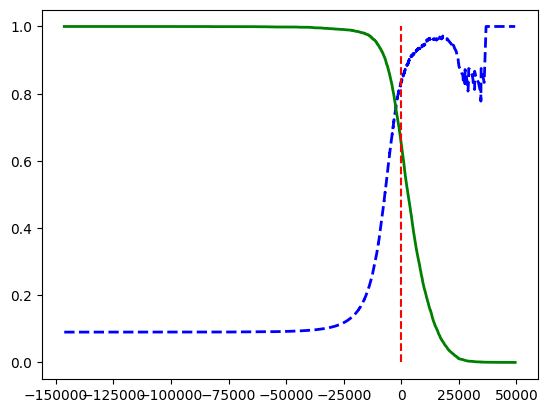

In [31]:
import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
threshold=0
plt.vlines(threshold, 0, 1, color="r", linestyle="--", label="Threshold")
plt.show()

---

## 📘 ROC Curve (Receiver Operating Characteristic Curve)

The **ROC Curve** is a graph that shows how well a **classification model** can separate two classes (Positive vs Negative) at different threshold values.

---

### 📊 Axes

* **X-axis:** False Positive Rate (FPR)

  $$
  FPR = \frac{FP}{FP + TN}
  $$

  (How many actual negatives were wrongly predicted as positive)

* **Y-axis:** True Positive Rate (TPR) = Recall

  $$
  TPR = \frac{TP}{TP + FN}
  $$

  (How many actual positives were correctly identified)

---

### 🎯 How it works

* Start with **different thresholds** (from 0 to 1).
* For each threshold, calculate **TPR** and **FPR**.
* Plot the points → that’s the ROC Curve.

---

### ✅ Ideal Curve

* A **perfect model** goes straight up to (0,1) and then across → it has **100% TPR and 0% FPR**.
* A **random model** (like coin flip) gives a diagonal line from (0,0) to (1,1).

---

### 📐 AUC (Area Under the Curve)

* The **AUC** value (0–1) summarizes the ROC Curve.

  * **1.0** → Perfect model
  * **0.5** → Random guessing (no skill)
  * **<0.5** → Worse than random

---

### 📩 Example (Spam Filter)

* If threshold is very low → almost all emails marked as spam → High Recall, but also high False Positives.
* If threshold is very high → only a few emails marked as spam → Low False Positives, but also low Recall.
* ROC Curve helps visualize this tradeoff across all thresholds.

---

✅ In short:
The **ROC Curve** tells you how well your model can distinguish between classes at all possible thresholds.
The **AUC** gives one number to summarize that performance.

---
